In [1]:
import numpy as np
from scipy.optimize import linprog

In [2]:
zones = [
    "Periyar Lake",
    "Periyar-Vandiperiyar",
    "Elappara",
    "Ayyappancoil",
    "Idukki Reservoir",
    "Neriamangalam",
    "Aluva",
    "Udhyogamandal",
    "Varapuzha",
    "Vembanad Lake",
    "Munambam"
]

In [3]:
available_units = 5

In [5]:
import pandas as pd

df = pd.read_csv("zone_features_final[2].csv")

In [6]:
population = df["Population Density"].to_numpy()

print(population)

[4612.28523151 5015.31020317 5546.12125235 5505.60145305 6040.13400882
 5648.1816188  4986.21859356 4691.24971496 4513.32856657 4513.32856657
 4822.62804954]


In [7]:
print(df["zone_name"].tolist())

['Periyar Lake', 'Periyar-Vandiperiyar', 'Elappara', 'Ayyappancoil', 'Idukki Reservoir', 'Neriamangalam', 'Aluva', 'Udhyogamandal', 'Varapuzha', 'Vembanad Lake', 'Munambam']


In [9]:
import pandas as pd

df = pd.read_csv("zone_features_final[2].csv")

print(df.columns)
print(df.head())

Index(['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)',
       'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)',
       'Population Density', 'Historical Floods', 'Flood Occurred', 'zone_id',
       'zone_name', 'lat', 'lon', 'district', 'STATE_UT_NAME', 'DISTRICT',
       'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT',
       'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec',
       'fatalities', 'no_of_camps', 'actual_rainfall_in_mm',
       'normal_rainfall_in_mm', 'no_of_landslides', 'full_damaged_houses'],
      dtype='object')
   Rainfall (mm)  Temperature (°C)  Humidity (%)  River Discharge (m³/s)  \
0     179.020074         32.803759     60.312370             2634.912132   
1     176.295573         33.106101     60.653973             2655.926103   
2     158.503117         33.422386     58.236913             2718.855050   
3     163.583666         32.813564     57.573909             2466.045114   
4     148.952103         3

In [10]:
print(df.columns)

Index(['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)',
       'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)',
       'Population Density', 'Historical Floods', 'Flood Occurred', 'zone_id',
       'zone_name', 'lat', 'lon', 'district', 'STATE_UT_NAME', 'DISTRICT',
       'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT',
       'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec',
       'fatalities', 'no_of_camps', 'actual_rainfall_in_mm',
       'normal_rainfall_in_mm', 'no_of_landslides', 'full_damaged_houses'],
      dtype='object')


In [11]:
import json

with open("stage1_output.json", "r") as f:
    risk_data = json.load(f)

risk = [risk_data[zone] for zone in zones]

print(risk)

[0.3756, 0.3705, 0.3376, 0.3008, 0.3424, 0.4095, 0.4381, 0.4617, 0.4774, 0.4929, 0.4806]


In [12]:
priority = []

for r, p in zip(risk, population):
    priority.append(r * p)

print(priority)

[np.float64(1732.3743329535373), np.float64(1858.1724302738214), np.float64(1872.3705347927682), np.float64(1656.0849170767465), np.float64(2068.14188462094), np.float64(2312.930372898877), np.float64(2184.462365838976), np.float64(2165.949993396658), np.float64(2154.6630576792763), np.float64(2224.6196504610707), np.float64(2317.7550406104524)]


In [13]:
priority = np.array(priority)

In [14]:
c = -priority

In [15]:
A = np.ones((1, len(zones)))
print(A)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [16]:
b = [available_units]
print(b)

[5]


In [17]:
bounds = [(0, 1)] * len(zones)

In [18]:
c = -priority

A = np.ones((1, len(zones)))

b = [available_units]

bounds = [(0, 1)] * len(zones)

In [19]:
print("len(zones):", len(zones))
print("len(priority):", len(priority))
print("priority:", priority)
print("A shape:", A.shape)
print("b:", b)

len(zones): 11
len(priority): 11
priority: [1732.37433295 1858.17243027 1872.37053479 1656.08491708 2068.14188462
 2312.9303729  2184.46236584 2165.9499934  2154.66305768 2224.61965046
 2317.75504061]
A shape: (1, 11)
b: [5]


In [20]:
print("Zones:", len(zones))
print(zones)

print("\nPopulation:", len(population))
print(population)

Zones: 11
['Periyar Lake', 'Periyar-Vandiperiyar', 'Elappara', 'Ayyappancoil', 'Idukki Reservoir', 'Neriamangalam', 'Aluva', 'Udhyogamandal', 'Varapuzha', 'Vembanad Lake', 'Munambam']

Population: 11
[4612.28523151 5015.31020317 5546.12125235 5505.60145305 6040.13400882
 5648.1816188  4986.21859356 4691.24971496 4513.32856657 4513.32856657
 4822.62804954]


In [21]:
print(df["zone_name"].tolist())

['Periyar Lake', 'Periyar-Vandiperiyar', 'Elappara', 'Ayyappancoil', 'Idukki Reservoir', 'Neriamangalam', 'Aluva', 'Udhyogamandal', 'Varapuzha', 'Vembanad Lake', 'Munambam']


In [22]:
result = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)

In [23]:
print(result.success)

True


In [24]:
print(result.x)

[ 0.  0.  0.  0.  0.  1.  1.  1. -0.  1.  1.]


In [25]:
allocation = np.round(result.x)

for zone, unit in zip(zones, allocation):
    if unit == 1:
        print(f"✅ Rescue Unit -> {zone}")
    else:
        print(f"❌ No Rescue Unit -> {zone}")

❌ No Rescue Unit -> Periyar Lake
❌ No Rescue Unit -> Periyar-Vandiperiyar
❌ No Rescue Unit -> Elappara
❌ No Rescue Unit -> Ayyappancoil
❌ No Rescue Unit -> Idukki Reservoir
✅ Rescue Unit -> Neriamangalam
✅ Rescue Unit -> Aluva
✅ Rescue Unit -> Udhyogamandal
❌ No Rescue Unit -> Varapuzha
✅ Rescue Unit -> Vembanad Lake
✅ Rescue Unit -> Munambam


In [26]:
coverage = np.sum(priority * allocation)

print("Total Coverage:", coverage)

Total Coverage: 11205.717423206035


In [27]:
import pandas as pd

df_lp = pd.DataFrame({
    "Zone": zones,
    "Risk": risk,
    "Population": population,
    "Priority": priority,
    "Allocated": allocation.astype(int)
})

print(df_lp)

                    Zone    Risk   Population     Priority  Allocated
0           Periyar Lake  0.3756  4612.285232  1732.374333          0
1   Periyar-Vandiperiyar  0.3705  5015.310203  1858.172430          0
2               Elappara  0.3376  5546.121252  1872.370535          0
3           Ayyappancoil  0.3008  5505.601453  1656.084917          0
4       Idukki Reservoir  0.3424  6040.134009  2068.141885          0
5          Neriamangalam  0.4095  5648.181619  2312.930373          1
6                  Aluva  0.4381  4986.218594  2184.462366          1
7          Udhyogamandal  0.4617  4691.249715  2165.949993          1
8              Varapuzha  0.4774  4513.328567  2154.663058          0
9          Vembanad Lake  0.4929  4513.328567  2224.619650          1
10              Munambam  0.4806  4822.628050  2317.755041          1


In [28]:
priority = np.array(priority)

order = np.argsort(priority)[::-1]

In [29]:
greedy_allocation = np.zeros(len(zones))

In [30]:
greedy_allocation[order[:available_units]] = 1

In [31]:
for zone, unit in zip(zones, greedy_allocation):
    if unit == 1:
        print(f"✅ Rescue Unit -> {zone}")
    else:
        print(f"❌ No Rescue Unit -> {zone}")

❌ No Rescue Unit -> Periyar Lake
❌ No Rescue Unit -> Periyar-Vandiperiyar
❌ No Rescue Unit -> Elappara
❌ No Rescue Unit -> Ayyappancoil
❌ No Rescue Unit -> Idukki Reservoir
✅ Rescue Unit -> Neriamangalam
✅ Rescue Unit -> Aluva
✅ Rescue Unit -> Udhyogamandal
❌ No Rescue Unit -> Varapuzha
✅ Rescue Unit -> Vembanad Lake
✅ Rescue Unit -> Munambam


In [32]:
greedy_coverage = np.sum(priority * greedy_allocation)

print("Greedy Coverage:", greedy_coverage)

Greedy Coverage: 11205.717423206035


In [33]:
print("LP Coverage      :", coverage)
print("Greedy Coverage  :", greedy_coverage)

if coverage > greedy_coverage:
    print("🏆 LP performs better")
elif greedy_coverage > coverage:
    print("🏆 Greedy performs better")
else:
    print("🤝 Both methods perform equally")

LP Coverage      : 11205.717423206035
Greedy Coverage  : 11205.717423206035
🤝 Both methods perform equally


In [34]:
comparison = {
    "Method": ["Linear Programming", "Greedy"],
    "Coverage": [coverage, greedy_coverage]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

               Method      Coverage
0  Linear Programming  11205.717423
1              Greedy  11205.717423


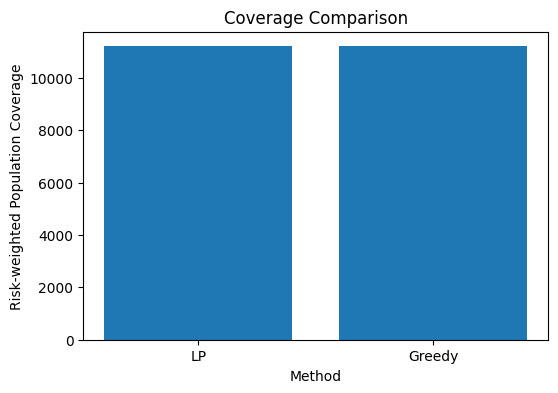

In [35]:
import matplotlib.pyplot as plt

methods = ["LP", "Greedy"]
scores = [coverage, greedy_coverage]

plt.figure(figsize=(6,4))
plt.bar(methods, scores)

plt.title("Coverage Comparison")
plt.xlabel("Method")
plt.ylabel("Risk-weighted Population Coverage")

plt.show()

In [56]:
comparison_df.to_csv("comparison_results.csv", index=False)

print("Results saved!")

Results saved!


In [37]:
import json

with open("stage1_output.json", "r") as f:
    risk_data = json.load(f)

print(risk_data)

{'Periyar Lake': 0.3756, 'Periyar-Vandiperiyar': 0.3705, 'Elappara': 0.3376, 'Ayyappancoil': 0.3008, 'Idukki Reservoir': 0.3424, 'Neriamangalam': 0.4095, 'Aluva': 0.4381, 'Udhyogamandal': 0.4617, 'Varapuzha': 0.4774, 'Vembanad Lake': 0.4929, 'Munambam': 0.4806}


In [38]:
risk = [risk_data[zone] for zone in zones]

print(risk)

[0.3756, 0.3705, 0.3376, 0.3008, 0.3424, 0.4095, 0.4381, 0.4617, 0.4774, 0.4929, 0.4806]


In [39]:
priority = []

for r, p in zip(risk, population):
    priority.append(r * p)

print(priority)

[np.float64(1732.3743329535373), np.float64(1858.1724302738214), np.float64(1872.3705347927682), np.float64(1656.0849170767465), np.float64(2068.14188462094), np.float64(2312.930372898877), np.float64(2184.462365838976), np.float64(2165.949993396658), np.float64(2154.6630576792763), np.float64(2224.6196504610707), np.float64(2317.7550406104524)]


In [40]:
priority = np.array(priority)

In [41]:
available_units = 5

In [42]:
c = -priority
A = np.ones((1, len(zones)))
b = [available_units]
bounds = [(0,1)] * len(zones)

result = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)

In [43]:
allocation = np.round(result.x)
coverage = np.sum(priority * allocation)

print("LP Coverage:", coverage)

LP Coverage: 11205.717423206035


In [44]:
order = np.argsort(priority)[::-1]

greedy_allocation = np.zeros(len(zones))
greedy_allocation[order[:available_units]] = 1

greedy_coverage = np.sum(priority * greedy_allocation)

print("Greedy Coverage:", greedy_coverage)

Greedy Coverage: 11205.717423206035


In [45]:
c = -priority
A = np.ones((1, len(zones)))
b = [available_units]
bounds = [(0,1)] * len(zones)

result = linprog(
    c,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)

In [46]:
print(result.success)
print(result.x)

True
[ 0.  0.  0.  0.  0.  1.  1.  1. -0.  1.  1.]


In [47]:
allocation = np.round(result.x)

for zone, unit in zip(zones, allocation):
    if unit == 1:
        print(f"✅ Rescue Unit -> {zone}")
    else:
        print(f"❌ No Rescue Unit -> {zone}")

❌ No Rescue Unit -> Periyar Lake
❌ No Rescue Unit -> Periyar-Vandiperiyar
❌ No Rescue Unit -> Elappara
❌ No Rescue Unit -> Ayyappancoil
❌ No Rescue Unit -> Idukki Reservoir
✅ Rescue Unit -> Neriamangalam
✅ Rescue Unit -> Aluva
✅ Rescue Unit -> Udhyogamandal
❌ No Rescue Unit -> Varapuzha
✅ Rescue Unit -> Vembanad Lake
✅ Rescue Unit -> Munambam


In [48]:
coverage = np.sum(priority * allocation)

print("LP Coverage:", coverage)

LP Coverage: 11205.717423206035


In [49]:
order = np.argsort(priority)[::-1]

greedy_allocation = np.zeros(len(zones))

greedy_allocation[order[:available_units]] = 1

In [50]:
for zone, unit in zip(zones, greedy_allocation):
    if unit == 1:
        print(f"✅ Rescue Unit -> {zone}")
    else:
        print(f"❌ No Rescue Unit -> {zone}")

❌ No Rescue Unit -> Periyar Lake
❌ No Rescue Unit -> Periyar-Vandiperiyar
❌ No Rescue Unit -> Elappara
❌ No Rescue Unit -> Ayyappancoil
❌ No Rescue Unit -> Idukki Reservoir
✅ Rescue Unit -> Neriamangalam
✅ Rescue Unit -> Aluva
✅ Rescue Unit -> Udhyogamandal
❌ No Rescue Unit -> Varapuzha
✅ Rescue Unit -> Vembanad Lake
✅ Rescue Unit -> Munambam


In [51]:
greedy_coverage = np.sum(priority * greedy_allocation)

print("Greedy Coverage:", greedy_coverage)

Greedy Coverage: 11205.717423206035


In [52]:
print("========== FINAL COMPARISON ==========")
print("LP Coverage     :", coverage)
print("Greedy Coverage :", greedy_coverage)

if coverage > greedy_coverage:
    print("🏆 LP performs better")
elif greedy_coverage > coverage:
    print("🏆 Greedy performs better")
else:
    print("🤝 Both methods perform equally")

========== FINAL COMPARISON ==========
LP Coverage     : 11205.717423206035
Greedy Coverage : 11205.717423206035
🤝 Both methods perform equally


In [53]:
import pandas as pd

In [54]:
comparison_df = pd.DataFrame({
    "Method": ["Linear Programming", "Greedy"],
    "Coverage": [coverage, greedy_coverage]
})

comparison_df.to_csv("comparison_results.csv", index=False)

print("Results saved!")

Results saved!
